Before Cleaning:

      Name Gender     Grade      Math   Science English  Total
0  'Navya'   male        11      47.0      63.0    74.0    184
1    ROHAN      F   Grade 3      16.0        77       8    101
2  'Aditi'      0  Grade 11  28 marks  43 marks    46.0    117
3     Myra   Male         7        74      12.0      72    158
4   ISHAAN   male        03  92 marks        27    25.0    144
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     1000 non-null   object
 1   Gender   1000 non-null   object
 2   Grade    1000 non-null   object
 3   Math     1000 non-null   object
 4   Science  1000 non-null   object
 5   English  1000 non-null   object
 6   Total    1000 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 54.8+ KB
None

Missing values:
 Name       0
Gender     0
Grade      0
Math       0
Science    0
English    0
Total      0
d

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_19341/209388984.py:31: SyntaxWarning: invalid escape sequence '\d'
  df['Grade'] = df['Grade'].astype(str).str.extract('(\d+)')
/tmp/ipykernel_19341/209388984.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


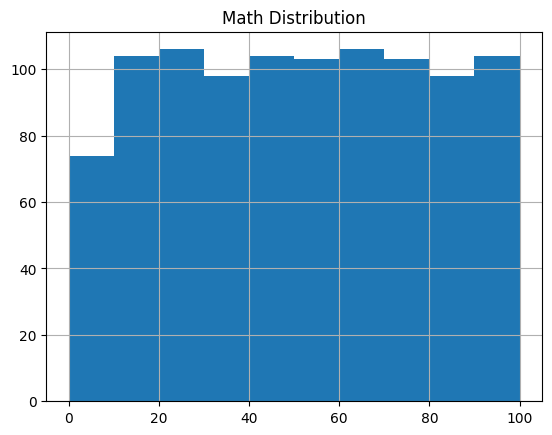

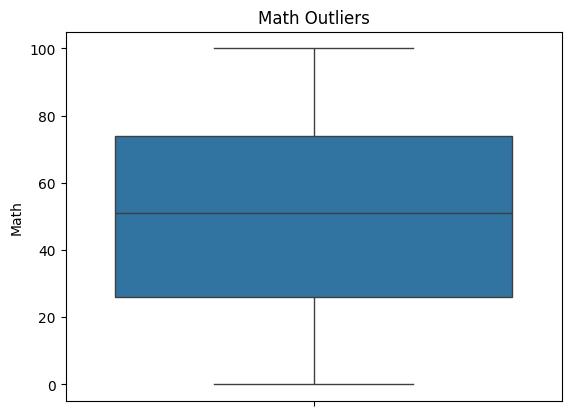

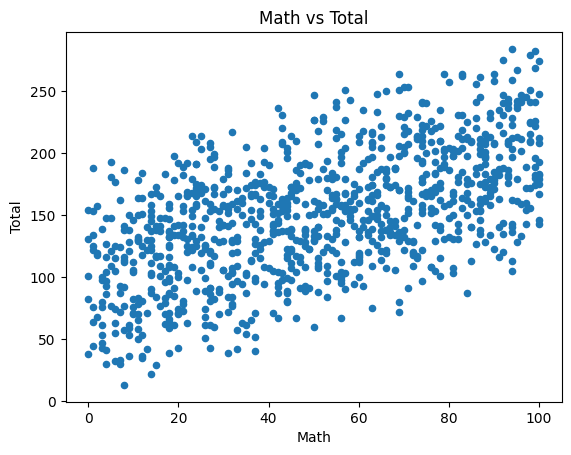

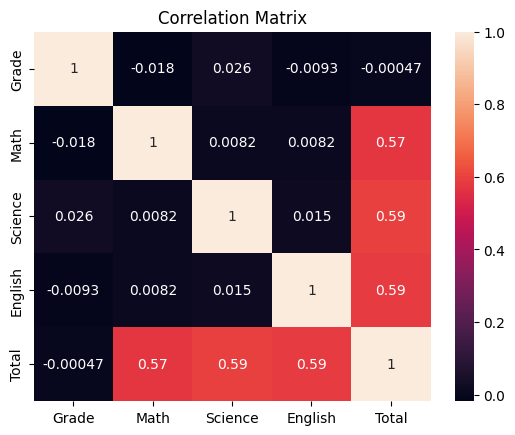


Cleaned Data Sample:

     Name   Gender  Grade  Math  Science  English  Total
0   Navya        M     11  47.0     63.0     74.0    184
1   Rohan        F      3  16.0     77.0      8.0    101
2   Aditi  Unknown     11  28.0     43.0     46.0    117
3    Myra        M      7  74.0     12.0     72.0    158
4  Ishaan        M      3  92.0     27.0     25.0    144


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv("/student_data_part1.csv")

print("Before Cleaning:\n")
print(df.head())
print(df.info())

# 2. DATA CLEANING

# --- Clean Name ---
df['Name'] = df['Name'].astype(str).str.replace("'", "").str.strip().str.title()

# --- Clean Gender ---
df['Gender'] = df['Gender'].astype(str).str.lower().str.strip()

df['Gender'] = df['Gender'].replace({
    'male': 'M', 'm': 'M',
    'female': 'F', 'f': 'F',
    '0': 'Unknown', '': 'Unknown'
})

# --- Clean Grade (extract numbers only) ---
df['Grade'] = df['Grade'].astype(str).str.extract('(\d+)')
df['Grade'] = pd.to_numeric(df['Grade'], errors='coerce')

# --- Clean Marks columns (remove "marks" text) ---
for col in ['Math', 'Science', 'English']:
    df[col] = df[col].astype(str).str.replace('marks', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. HANDLE MISSING VALUES
print("\nMissing values:\n", df.isnull().sum())

# Fill numeric missing with median
for col in ['Math', 'Science', 'English', 'Grade']:
    df[col].fillna(df[col].median(), inplace=True)

# 4. REMOVE DUPLICATES
df.drop_duplicates(inplace=True)

# 5. VERIFY CLEANED DATA
print("\nAfter Cleaning:\n")
print(df.info())
print(df.describe())

# 6. EDA VISUALIZATION

# Histogram
df['Math'].hist()
plt.title("Math Distribution")
plt.show()

# Boxplot (Outliers)
sns.boxplot(df['Math'])
plt.title("Math Outliers")
plt.show()

# Scatter plot
df.plot.scatter(x='Math', y='Total')
plt.title("Math vs Total")
plt.show()

# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# 7. FINAL OUTPUT
print("\nCleaned Data Sample:\n")
print(df.head())